```text
Model diagnostics
├── Import & Setup
├── Champion-Challenger definition
├── Explainability
└── Fairness   
```

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import explain_model
from src.feature_engineering import create_target_def12
from src.modelling import apply_pipe
from src.plots import my_calibration
from src.preprocessing import my_input_load, ReplaceMinusOne

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# load input file

portfolio = my_input_load(2019, 2020)
portfolio, dr_summary = create_target_def12(portfolio)

LoanDate range:     2019-01-01 00:00:00 2020-12-31 00:00:00
+12 months:         2020-01-01 00:00:00 2021-12-31 00:00:00
DefaultDate range:  2019-04-26 00:00:00 2023-10-13 00:00:00


LoanYear,num_loans,num_defaults,default_rate
2019,28487,4879,0.171271
2020,19959,2294,0.114936


## Champion - Challenger definition

In this notebook i address the topics of model **explainability** and **fairness** where:
1. Champion: Logistic Regression model
1. Challenger: Gradient Boosting model

In [4]:
# import pipelines

import joblib
pipeline_champ = joblib.load("../models/PIPELINE_PD_ver_012.pkl")
pipeline_chall = joblib.load("../models/PIPELINE_PD_ver_012_GB.pkl")

In [5]:
# apply pipelines

portfolio_champ = apply_pipe(portfolio, pipeline_champ)
portfolio_chall = apply_pipe(portfolio, pipeline_chall)

In [6]:
# check models against observations

#my_calibration(portfolio_champ["default12"], portfolio_champ["PD"], dataset_name="", show_cal_table=False, plot_title="Champion")
#my_calibration(portfolio_chall["default12"], portfolio_chall["PD"], dataset_name="", show_cal_table=False, plot_title="Challenger")

## Explainability

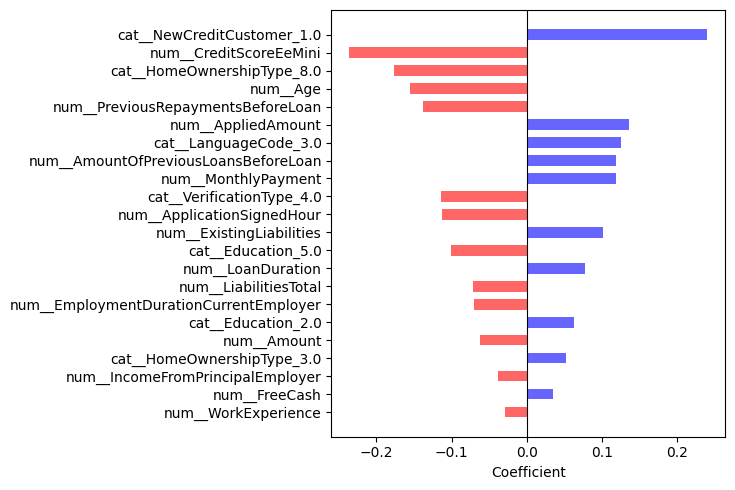

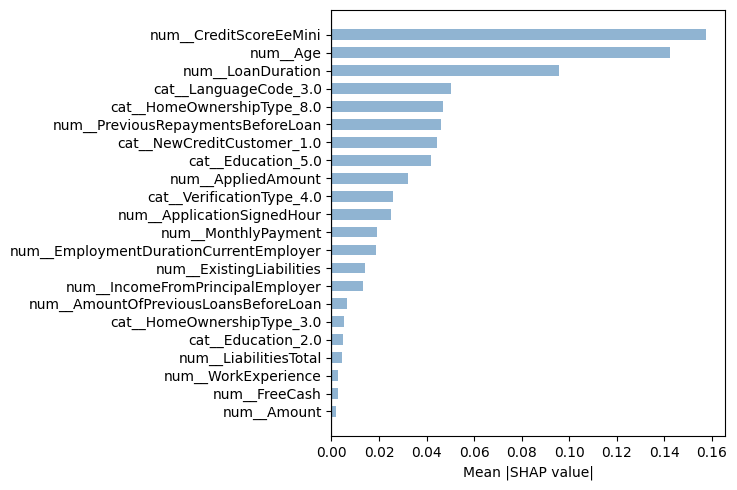

In [7]:
# Global

explanation_champ = explain_model(pipeline_champ, portfolio)
explanation_chall = explain_model(pipeline_chall, portfolio)


## Fairness